### EDA and Data Analysis

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
df_data = pl.read_parquet(r"C:\Users\elmaz\AIProject\NASA_Project\data\raw_data\features_train.parquet")

In [3]:
train_data = df_data.to_pandas()
train_data.head(5)

,ax,ay,mag,ax_diff,ay_diff,mag_diff,source_file
0,-0.176,-0.199,0.265663,0.000,0.000,0.000000,acc_01192.csv
1,-0.038,-0.030,0.048415,0.138,0.169,-0.217248,acc_01192.csv
2,-0.029,-0.261,0.262606,0.009,-0.231,0.214191,acc_01192.csv
3,-0.169,0.271,0.319378,-0.140,0.532,0.056771,acc_01192.csv
4,-0.241,0.612,0.657742,-0.072,0.341,0.338365,acc_01192.csv


In [4]:
train_data["source_file"].nunique()

2803

In [5]:
counts = train_data.groupby("source_file").size()
print(counts)

source_file
acc_00001.csv    15360
acc_00002.csv    15360
acc_00003.csv    15360
acc_00004.csv    15360
acc_00005.csv    15360
                 ...  
acc_02799.csv     2560
acc_02800.csv     2560
acc_02801.csv     2560
acc_02802.csv     2560
acc_02803.csv     2560
Length: 2803, dtype: int64


In [6]:
summary_table = counts.value_counts().sort_index(ascending=False)
print(summary_table)

15360     515
12800     282
10240      74
7680       40
5120      726
2560     1166
Name: count, dtype: int64


In [7]:
changes = counts[counts != counts.shift()].index
print("Files where row count changes (bearing failure points):")
print(changes)

Files where row count changes (bearing failure points):
Index(['acc_00001.csv', 'acc_00516.csv', 'acc_00798.csv', 'acc_00872.csv',
       'acc_00912.csv', 'acc_01638.csv'],
      dtype='str', name='source_file')


In [8]:
summary_table = summary_table.to_dict()

In [9]:
summary_table

{15360: 515, 12800: 282, 10240: 74, 7680: 40, 5120: 726, 2560: 1166}

In [10]:
train_data2 = train_data.copy()

In [11]:
file_lengths = train_data2.groupby("source_file").size()
file_lengths

source_file
acc_00001.csv    15360
acc_00002.csv    15360
acc_00003.csv    15360
acc_00004.csv    15360
acc_00005.csv    15360
                 ...  
acc_02799.csv     2560
acc_02800.csv     2560
acc_02801.csv     2560
acc_02802.csv     2560
acc_02803.csv     2560
Length: 2803, dtype: int64

In [12]:
BEARING_LIFETIMES = {
    'Bearing1_1': 2803,
    'Bearing1_2': 871,
    'Bearing2_1': 797,
    'Bearing2_2': 911,
    'Bearing3_1': 515,
    'Bearing3_2': 1637,
}

def assign_bearing_ids(df, bearing_lifetimes):
    """Assigns bearing_id to every row based on (step, block_idx) lookup."""
    df = df.copy()

    # Step number from filename: acc_00123.csv -> 123
    df['step'] = df['source_file'].str.extract(r'(\d+)').astype(int)

    # Row position within each file (order-independent)
    df['row_in_file'] = df.groupby('source_file').cumcount()

    # Which 2560-row block: 0, 1, 2, ...
    df['block_idx'] = df['row_in_file'] // 2560

    # Build lookup: (step, block_idx) -> bearing_id
    lookup_rows = []
    for step in range(1, max(bearing_lifetimes.values()) + 1):
        alive = sorted([b for b, life in bearing_lifetimes.items() if step <= life])
        for idx, bid in enumerate(alive):
            lookup_rows.append({'step': step, 'block_idx': idx, 'bearing_id': bid})

    lookup = pd.DataFrame(lookup_rows)

    # Merge -- row order does not matter, matched on (step, block_idx)
    df = df.merge(lookup, on=["step", "block_idx"], how="left")
    return df


train_data2 = assign_bearing_ids(train_data, BEARING_LIFETIMES)

print(train_data2['bearing_id'].value_counts().sort_index())
print(f'Total NaN bearing_id: {train_data2["bearing_id"].isna().sum()}')

bearing_id
Bearing1_1    7175680
Bearing1_2    2229760
Bearing2_1    2040320
Bearing2_2    2332160
Bearing3_1    1318400
Bearing3_2    4190720
Name: count, dtype: int64
Total NaN bearing_id: 0


In [13]:
# Validation: how many steps did each bearing run?
check = (
    train_data2.groupby('bearing_id')['step']
    .agg(first_step='min', last_step='max', total_steps='nunique')
    .sort_index()
)
print(check)

# Split into separate DataFrames per bearing
bearings = {bid: grp.reset_index(drop=True)
            for bid, grp in train_data2.groupby('bearing_id')}

print("Bearings separated:")
for bid, df in sorted(bearings.items()):
    print(f"  {bid}: {len(df):>8,} rows  |  {df["step"].nunique()} steps")

            first_step  last_step  total_steps
bearing_id                                    
Bearing1_1           1       2803         2803
Bearing1_2           1        871          871
Bearing2_1           1        797          797
Bearing2_2           1        911          911
Bearing3_1           1        515          515
Bearing3_2           1       1637         1637
Bearings separated:
  Bearing1_1: 7,175,680 rows  |  2803 steps
  Bearing1_2: 2,229,760 rows  |  871 steps
  Bearing2_1: 2,040,320 rows  |  797 steps
  Bearing2_2: 2,332,160 rows  |  911 steps
  Bearing3_1: 1,318,400 rows  |  515 steps
  Bearing3_2: 4,190,720 rows  |  1637 steps


In [14]:
# Total steps per bearing
bearing_steps = (
    train_data2.groupby('bearing_id')['step']
    .nunique()
    .sort_values()
    .reset_index()
)
bearing_steps.columns = ['bearing_id', 'total_steps']
bearing_steps['duration_hours'] = (bearing_steps['total_steps'] * 10 / 3600).round(2)

print(bearing_steps.to_string(index=False))

bearing_id  total_steps  duration_hours
Bearing3_1          515            1.43
Bearing2_1          797            2.21
Bearing1_2          871            2.42
Bearing2_2          911            2.53
Bearing3_2         1637            4.55
Bearing1_1         2803            7.79


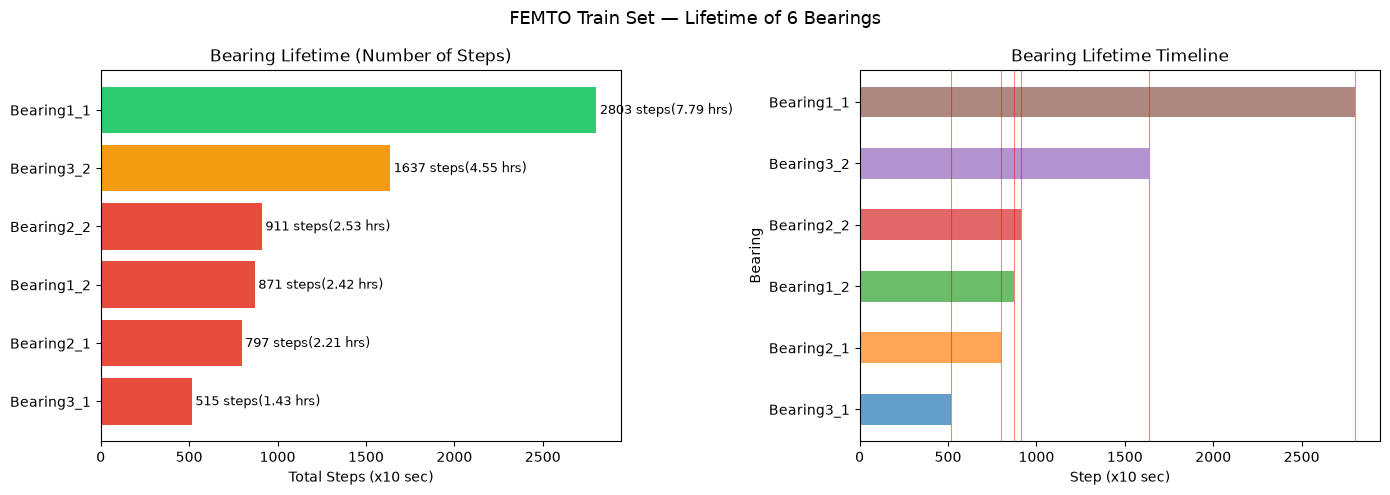

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: step count bar chart
colors = ['#e74c3c' if s < 1000 else '#f39c12' if s < 2000 else '#2ecc71'
          for s in bearing_steps['total_steps']]

axes[0].barh(bearing_steps['bearing_id'], bearing_steps['total_steps'], color=colors)
axes[0].set_xlabel('Total Steps (x10 sec)')
axes[0].set_title('Bearing Lifetime (Number of Steps)')
for i, (steps, hours) in enumerate(zip(bearing_steps['total_steps'], bearing_steps['duration_hours'])):
    axes[0].text(steps + 20, i, f'{steps} steps({hours} hrs)', va='center', fontsize=9)

# Right: timeline — when did each bearing fail
axes[1].set_title('Bearing Lifetime Timeline')
for i, row in bearing_steps.iterrows():
    axes[1].barh(row['bearing_id'], row['total_steps'],
                 left=0, height=0.5, alpha=0.7)
    axes[1].axvline(row['total_steps'], color='red', linewidth=0.8, alpha=0.5)

axes[1].set_xlabel('Step (x10 sec)')
axes[1].set_ylabel('Bearing')

plt.suptitle('FEMTO Train Set — Lifetime of 6 Bearings', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
train_data2.isnull().sum()

ax             0
ay             0
mag            0
ax_diff        0
ay_diff        0
mag_diff       0
source_file    0
step           0
row_in_file    0
block_idx      0
bearing_id     0
dtype: int64

In [17]:
train_data2.duplicated().sum()

np.int64(0)

In [18]:
train_data2.groupby("bearing_id")[["ax", "ay"]].apply(lambda g: g.isnull().sum())

,ax,ay
bearing_id,,
Bearing1_1,0,0
Bearing1_2,0,0
Bearing2_1,0,0
Bearing2_2,0,0
Bearing3_1,0,0
Bearing3_2,0,0


In [19]:
bearing_steps = (
    train_data2.groupby('bearing_id')['step']
    .nunique()
    .sort_values()
    .reset_index()
)
bearing_steps.columns = ['bearing_id', 'total_steps']
bearing_steps

,bearing_id,total_steps
0,Bearing3_1,515
1,Bearing2_1,797
2,Bearing1_2,871
3,Bearing2_2,911
4,Bearing3_2,1637
5,Bearing1_1,2803


In [20]:
mapping_dict = {
    'Bearing3_1': 'bearing_1',
    'Bearing2_1': 'bearing_2',
    'Bearing1_2': 'bearing_3',
    'Bearing2_2': 'bearing_4',
    'Bearing3_2': 'bearing_5',
    'Bearing1_1': 'bearing_6'
}

train_data2["bearing_id"].unique().tolist()

['Bearing1_1',
 'Bearing1_2',
 'Bearing2_2',
 'Bearing2_1',
 'Bearing3_1',
 'Bearing3_2']

In [21]:
train_data2["bearing_id"] = train_data2["bearing_id"].map(mapping_dict)
print("Revised bearings names :", train_data2["bearing_id"].unique().tolist())

Revised bearings names : ['bearing_6', 'bearing_3', 'bearing_4', 'bearing_2', 'bearing_1', 'bearing_5']


In [22]:
train_data2

,ax,ay,mag,ax_diff,ay_diff,mag_diff,source_file,step,row_in_file,block_idx,bearing_id
0,-0.176,-0.199,0.265663,0.000,0.000,0.000000,acc_01192.csv,1192,0,0,bearing_6
1,-0.038,-0.030,0.048415,0.138,0.169,-0.217248,acc_01192.csv,1192,1,0,bearing_6
2,-0.029,-0.261,0.262606,0.009,-0.231,0.214191,acc_01192.csv,1192,2,0,bearing_6
3,-0.169,0.271,0.319378,-0.140,0.532,0.056771,acc_01192.csv,1192,3,0,bearing_6
4,-0.241,0.612,0.657742,-0.072,0.341,0.338365,acc_01192.csv,1192,4,0,bearing_6
...,...,...,...,...,...,...,...,...,...,...,...
19287035,0.031,-0.148,0.151212,0.071,-0.330,-0.035132,acc_01180.csv,1180,5115,1,bearing_5
19287036,-0.087,-0.043,0.097046,-0.118,0.105,-0.054165,acc_01180.csv,1180,5116,1,bearing_5
19287037,0.085,0.283,0.295489,0.172,0.326,0.198443,acc_01180.csv,1180,5117,1,bearing_5
19287038,0.095,-0.263,0.279632,0.010,-0.546,-0.015858,acc_01180.csv,1180,5118,1,bearing_5


In [23]:
print(train_data2.info())

<class 'pandas.DataFrame'>
RangeIndex: 19287040 entries, 0 to 19287039
Data columns (total 11 columns):
 #   Column       Dtype  
---  ------       -----  
 0   ax           float32
 1   ay           float32
 2   mag          float32
 3   ax_diff      float32
 4   ay_diff      float32
 5   mag_diff     float32
 6   source_file  str    
 7   step         int64  
 8   row_in_file  int64  
 9   block_idx    int64  
 10  bearing_id   str    
dtypes: float32(6), int64(3), str(2)
memory usage: 1.5 GB
None


In [24]:
train_data2.to_parquet(r"C:\Users\elmaz\AIProject\NASA_Project\data\processed_data\processed_train_data.parquet")